In [1]:
%load_ext autoreload
%autoreload 2

# Import the library
import greenlearning as gl
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import time
import os

Using TensorFlow 2 backend.

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
np.random.seed(42)

# N_train_arr = np.concat((np.linspace(2, 20, 10, endpoint=True, dtype=int), np.linspace(25, 75, 11, endpoint=True, dtype=int)))
# N_train_arr = np.array([1, 5, 10, 15, 20, 25, 30])
N_train_arr = np.array([20])
noise_ratio = 0e-2
resample = 1
repeats = range(5)

filename = 'results_csv_wall_time/train_wall_time_vs_N_train.csv'

for i in repeats:
    for N_train in N_train_arr:

        # Construct neural networks for G and homogeneous solution
        G_network = gl.matrix_networks([2] + [50] * 4 + [1], "rational", (1,1))
        U_hom_network = gl.matrix_networks([1] + [50] * 4 + [1], "rational", (1,))

        s_time = time.time()
        # Define the model
        model = gl.Model(G_network, U_hom_network, N_train=N_train, noise_ratio=noise_ratio, resample=resample, repeat=i, adam_steps=10, lbfgs_steps=10)

        # Train the model on the dataset "helmholtz" in the path "examples/datasets/"
        model.train("examples/datasets/","helmholtz")
        e_time = time.time()

        time_elapsed = e_time - s_time

        df = pd.DataFrame({'N_train': [N_train], 'noise_ratio': [noise_ratio], 'resample': [resample], 'repeat': [i], 'train_wall_time': [time_elapsed]})

        # if file exists, append without header
        if os.path.isfile(filename):
            df.to_csv(filename, mode="a", header=False, index=False)
        else:
            # create file with header
            df.to_csv(filename, mode="w", header=True, index=False)

        # Close the TensorFlow session
        model.sess.close()

It: 0, Loss = 1.006e+00
INFO:tensorflow:Optimization terminated with:
  Message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  Objective function value: 0.967142
  Number of iterations: 10
  Number of functions evaluations: 13
It: 0, Loss = 1.174e+00
INFO:tensorflow:Optimization terminated with:
  Message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  Objective function value: 0.967233
  Number of iterations: 10
  Number of functions evaluations: 13


KeyboardInterrupt: 

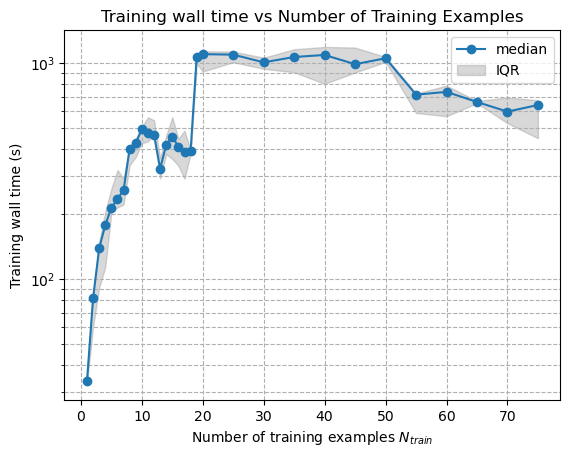

<Axes: xlabel='N_train'>

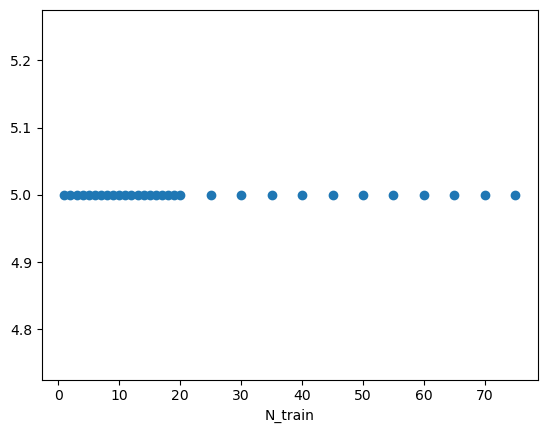

In [2]:
data = pd.read_csv('results_csv_wall_time/train_wall_time_vs_N_train.csv')

# group by N_train and compute mean and std of relative_L2_error
grouped = data.groupby('N_train')['train_wall_time'].agg(median='median', q25=lambda x: np.percentile(x, 25), q75=lambda x: np.percentile(x, 75)).reset_index()

plt.figure()
plt.plot(grouped['N_train'], grouped['median'], 'o-', label='median')
plt.fill_between(grouped['N_train'], grouped['q25'], grouped['q75'], color='gray', alpha=0.3, label='IQR')
# plt.errorbar(grouped['N_train'], grouped['median'], yerr=[grouped['q25'], grouped['q75']], fmt='o-', capsize=5, linestyle='None', label='IQR')
plt.yscale('log')
plt.xlabel('Number of training examples $N_{train}$')
plt.ylabel('Training wall time (s)')
plt.title('Training wall time vs Number of Training Examples')
plt.grid(True, which="both", ls="--")
plt.legend()
# plt.savefig('train_wall_time_vs_N_train.png', dpi=300)
plt.show()

# count entries for each N_train
data['N_train'].value_counts().plot(kind='line', linestyle='None', marker='o')